# 🚌 **AICE ASSOCIATE 제4회 실전모의고사**
## **제주 버스 운행 시간 예측**

---
- **도메인**: 대중교통 및 물류
- **목 표**: 다양한 운행 조건을 고려하여 버스의 실제 **총 운행 시간(travel_time)을 예측**하는 인공지능 모델 개발
- 버스 회사 '에듀버스(Edu-Bus)'는 기존의 고정된 시간표 기반 도착 예측 시스템이 날씨 변화나 교통 체증과 같은 유동적인 변수를 실시간으로 반영하지 못해 승객들의 불만이 지속적으로 제기되고 있다.
- 이러한 문제를 해결하기 위해, 에듀버스의 데이터 분석팀은 과거 운행 기록, 실시간 교통 상황, 기상 데이터 등 다양한 변수를 종합적으로 분석하여 **실제 버스 운행 시간을 정확하게 예측** 하는 AI 모델을 도입하려 한다.
---

### **[데이터셋 소개]**
**1. 훈련용 데이터**
* **train_bus_driving_record.csv**
* **train_bus_environment.json**

**2. 테스트용 데이터**
* **test_bus_driving_record.csv**
* **test_bus_environment.json**

### **[데이터 컬럼 설명]**
**1. train/test_bus_driving_record.csv 파일 컬럼**
* **record_id**: 운행 기록 고유 ID
* **bus_route_id**: 버스 노선 ID
* **date**: 운행 날짜
* **time**: 출발 시간
* **day_of_week**: 요일
* **bus_stop_id**: 출발 정류장 ID

**2. train/test_bus_environment.json 파일 컬럼**
* **record_id**: 운행 기록 고유 ID
* **temperature**: 출발 시 온도
* **weather**: 당시 날씨
* **traffic_congestion**: 교통 혼잡도('Low', 'Medium', 'High', 'Severe')
* **travel_time**: 총 운행 시간 (분) - **Target**

#### **1. 분석에 필요한 버스 운행 기록(CSV)과 도로 환경 데이터(JSON)를 로드하고 구조를 확인하세요. 아래 가이드에 따라 데이터를 불러오고 통합하세요**
---
* **(1-1) 훈련용(train)과 테스트용(test) 데이터를 각각 불러와 병합하세요.**
    - `pandas` 라이브러리를 `pd` 별칭으로 임포트하세요.
    - train_driving_record.csv 와 train_bus_environment.json을 각각 불러와 record_id를 기준으로 병합하여 train_df 생성하세요.
    - test_driving_record.csv 와 test_bus_environment.json을 각각 불러와 record_id를 기준으로 병합하여 test_df 생성하세요.
    - train_df에 대해 상위 5개의 데이터를 출력하세요.
* **(1-2) 예측할 타겟 변수(travel_time)의 데이터 타입을 확인하고, 이 문제의 유형이 '회귀'와 '분류' 중 무엇인지 기입하세요.**
---

In [1]:
import pandas as pd

train_bus_driving = pd.read_csv('train_bus_driving_record.csv')
train_bus_envir = pd.read_json('train_bus_environment.json')
test_bus_driving = pd.read_csv('test_bus_driving_record.csv')
test_bus_envir = pd.read_json('test_bus_environment.json')

train_df = pd.merge(train_bus_driving, train_bus_envir, on='record_id')
test_df = pd.merge(test_bus_driving, test_bus_envir, on='record_id')

train_df.head()
                               


,record_id,bus_route_id,date,time,day_of_week,bus_stop_id,temperature,weather,traffic_congestion,travel_time
0,0,route_A,2025-01-01,00:00:00,Wednesday,stop_19,NaN,None,Low,16.18
1,1,route_C,2025-01-01,00:30:00,Wednesday,stop_8,9.843231,None,Low,16.05
2,2,route_B,2025-01-01,01:00:00,Wednesday,stop_7,NaN,Sunny,High,21.36
3,3,route_B,2025-01-01,01:30:00,Wednesday,stop_16,14.827113,Sunny,Medium,26.45
4,4,route_A,2025-01-01,02:00:00,Wednesday,stop_19,9.555564,Sunny,Low,22.48


In [ ]:
# (1-2) 여기에 답안을 입력하세요(실행 불필요)

#### **2. 조건부 데이터 추출을 통해 특정 노선의 주말 운행 시간(travel_time)을 분석하세요.**
---
* **대상 데이터**: **`train_df`**
* **(2-1) 특정 노선 및 주말 데이터 추출**
    - **`bus_route_id`** 가 **'route_B'** 인 데이터와 **`day_of_week`** 가 **'Saturday'** 또는 **'Sunday'** 인 데이터를 결합하여 추출하세요.
    - travel_time 컬럼에 대한 평균값을 계산하세요. (소수점 둘째 자리까지 반올림)
* **(2-2) 계산된 route_B 노선의 **평균 주말 운행 시간**은 얼마인지 기입하세요.**
---

In [2]:
cond1 = train_df['bus_route_id'] == 'route_B'
cond2 = train_df['day_of_week'].isin(['Saturday', 'Sunday'])
cond = train_df[cond1 & cond2]

print(round(cond['travel_time'].mean(),2))

26.51


In [ ]:
# (2-2) 여기에 답안을 입력하세요(실행 불필요),

#### **3. 날짜 데이터를 활용하여 '월(month)' 파생 변수를 생성하고 분석하세요.**
---
* **대상 데이터**: **`train_df`**, **`test_df`**
* **(3-1) 날짜 데이터 변환 및 파생 변수 생성**
    - **`train_df`** 와 **`test_df`** 각각의 **`date`** 컬럼을 **날짜형(datetime)** 으로 변환하세요.
    - 변환된 **`date`** 컬럼에서 **'월(month)'** 정보만 추출하여 **'month'** 라는 새로운 컬럼을 두 데이터프레임에 모두 생성하세요.
    - 파생 변수 'month'가 잘 생성되었는지 train_df에 대해 상위 5개의 데이터를 출력하세요.
* **(3-2) 월별 운행 시간 분석**
    - **`train_df`** 를 활용하여 월별 **`travel_time`** 의 평균을 계산하세요.
* **(3-3) 평균 운행 시간이 가장 길었던 달(month)을 기입하세요.**
---

In [3]:
train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])

train_df['month'] = train_df['date'].dt.month
test_df['month'] = test_df['date'].dt.month

train_df.head()

,record_id,bus_route_id,date,time,day_of_week,bus_stop_id,temperature,weather,traffic_congestion,travel_time,month
0,0,route_A,2025-01-01,00:00:00,Wednesday,stop_19,NaN,None,Low,16.18,1
1,1,route_C,2025-01-01,00:30:00,Wednesday,stop_8,9.843231,None,Low,16.05,1
2,2,route_B,2025-01-01,01:00:00,Wednesday,stop_7,NaN,Sunny,High,21.36,1
3,3,route_B,2025-01-01,01:30:00,Wednesday,stop_16,14.827113,Sunny,Medium,26.45,1
4,4,route_A,2025-01-01,02:00:00,Wednesday,stop_19,9.555564,Sunny,Low,22.48,1


In [5]:
print(train_df.groupby(by='month')['travel_time'].mean())

month
1    27.123165
2    26.685231
3    26.904435
4    26.906985
Name: travel_time, dtype: float64


In [ ]:
# (3-3) 여기에 답안을 작성하고 실행하세요(실행 불필요).

> **<span style="color:red">다음 문항을 풀기 전에 </span>아래 코드를 실행하세요.**
>

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### **4. 총 운행 시간 (travel_time)의 이상치를 박스플롯(Boxplot)으로 확인하고 제거하세요.**
---
* **대상 데이터**: **`train_df`**
* **(4-1) 데이터 분포 시각화**
    - **`seaborn`** 라이브러리의 **`boxplot`** 을 사용하여 **`train_df`** 의 **`travel_time`** 분포를 시각화하세요.
* **(4-2) 이상치 제거 및 데이터 정제**
    - 운행 시간(**`travel_time`**)이 **80분을 초과** 하는 데이터를 이상치로 간주하여 해당 행들을 **`train_df`** 에서 삭제하세요.
    - 삭제 후 **`train_df`** 에 남아있는 전체 행(Row)의 개수를 출력하여 확인하세요.
---

<Axes: ylabel='travel_time'>

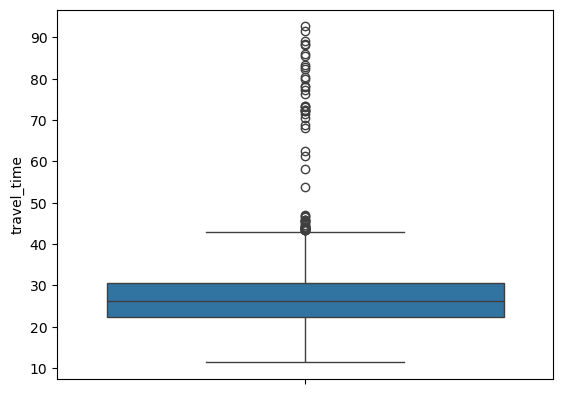

In [7]:
sns.boxplot(train_df, y='travel_time')

In [14]:
train_df = train_df[train_df['travel_time'] <= 80]

len(train_df)

4989

#### **5. 데이터에 결측치가 있을 경우 AI 모델링의 성능이 저하될 수 있습니다. 아래 가이드에 따라 결측치를 확인하고 검증하는 데 에러가 나고 있습니다. 코드의 오류를 정정하세요.**
---
* **대상 데이터**: **`train_df`**
* **(5-1) 아래 가이드에 따라 코드를 완성하고 실행하세요.**
    - 데이터프레임의 컬럼별 결측치 개수를 확인하세요.
    - **`weather`** 컬럼에 결측치가 있는 행을 모두 제거하세요.
    - **`temperature`** 컬럼의 결측치는 해당 컬럼의 **중앙값(median)** 으로 채우도록 코드를 수정하세요.
* **(5-2) 모든 처리가 완료된 후, **`temperature`** 컬럼의 중앙값(median)은 얼마인가요?**
---

In [15]:
# (5-1) 여기에 코드의 오류를 정정하고 실행하세요.
print("--- 처리 전 결측치 상태 ---")
print(train_df.isnull().sum())

train_df = train_df.dropna(subset=['weather'])
train_df['temperature'] = train_df['temperature'].fillna(train_df['temperature'].median())

print("--- 처리 후 결측치 상태 ---")
print(train_df.isnull().sum())

--- 처리 전 결측치 상태 ---
record_id             0
bus_route_id          0
date                  0
time                  0
day_of_week           0
bus_stop_id           0
temperature           2
weather               2
traffic_congestion    0
travel_time           0
month                 0
dtype: int64
--- 처리 후 결측치 상태 ---
record_id             0
bus_route_id          0
date                  0
time                  0
day_of_week           0
bus_stop_id           0
temperature           0
weather               0
traffic_congestion    0
travel_time           0
month                 0
dtype: int64


In [16]:
train_df['temperature'].median()

21.06449303125

#### **6. 아래 지시사항에 따라 범주형 변수를 수치형 데이터로 인코딩(Encoding) 하세요. 모델이 데이터의 논리적 순서와 범주 특성을 정확히 학습할 수 있도록 적절한 인코딩 함수와 옵션을 사용하여 수치형 피처로 변환하세요.**
---
* **대상 데이터**: **`train_df`**, **`test_df`**
* **순서형 변수 인코딩(Ordinal Encoding)**
    - **`traffic_congestion`** 컬럼은 'Low'(0) < 'Medium'(1) < 'High'(2) < 'Severe'(3) 순으로 매핑하여 숫자로 변환하세요.
    - 사전(dict) 기반 매핑 함수를 사용하여 논리적 순서가 유지되도록 인코딩하세요.
* **명목형 변수 인코딩(One-Hot Encoding)**
    - **`weather`** 와 **`day_of_week`** 컬럼에 대해 원-핫 인코딩을 수행하세요.
    - 다중공선성 방지 옵션과 생성된 값의 데이터 타입(정수형)을 지정하여 변환하세요.
---

In [19]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
map_6 = {'Low': 0, 'Medium': 1, 'High': 2, 'Severe': 3}
train_df['traffic_congestion'] = train_df['traffic_congestion'].map(map_6)
test_df['traffic_congestion'] = test_df['traffic_congestion'].map(map_6)

train_df = pd.get_dummies(train_df, columns=['weather', 'day_of_week'], drop_first=True, dtype=int)
test_df = pd.get_dummies(test_df, columns=['weather', 'day_of_week'], drop_first=True, dtype=int)

In [ ]:
# (6-1) 여기에 <#6-1>의 답안을 입력하세요(실행 불필요).

In [ ]:
# (6-2) 여기에 <#6-2>의 답안을 입력하세요(실행 불필요).

In [ ]:
# (6-3) 여기에 <#6-3>의 답안을 입력하세요(실행 불필요).

In [ ]:
# (6-4) 여기에 <#6-4>의 답안을 입력하세요(실행 불필요).

#### **7. 학습에 직접적인 영향을 주지 않거나 데이터 누수(Data Leakage)를 유발할 수 있는 식별자 및 중복 컬럼을 제거하여 최종 피처를 확정하세요. 아래 가이드에 따라 코드를 완성하세요.**
---
* **대상 데이터** : **`train_df`**, **`test_df`**
* **(7-1) 불필요한 컬럼 제거**
    - 제공된 **`cols_to_drop`**  리스트를 활용하여 **`train_df`** 와 **`test_df`** 에서 해당 컬럼들을 모두 삭제하세요.
    - 삭제가 완료된 후, **`train_df`** 의 최종 컬럼 목록을 출력하여 확인하세요.
* **(7-2)`train_df`의 전체 컬럼(Columns)은 몇 개인가요?**
---

In [20]:
# 이 코드를 먼저 실행하세요.
cols_to_drop = ['date', 'time', 'record_id', 'bus_route_id', 'bus_stop_id']

train_df = train_df.drop(columns=cols_to_drop, axis=1)
test_df = test_df.drop(columns=cols_to_drop, axis=1)

train_df.columns


Index(['temperature', 'traffic_congestion', 'travel_time', 'month',
       'weather_Heavy Snow', 'weather_Rain', 'weather_Sunny',
       'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday',
       'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday'],
      dtype='object')

In [24]:
len(train_df.columns)

13

In [ ]:
13

#### **8. 모델의 객관적인 성능 평가를 위해 학습 데이터셋을 훈련용(Train)과 검증용(Validation)으로 분할하세요. 아래 가이드에 따라 코드의 빈칸을 채우고 실행하세요.**
---
* **대상 데이터**: **`train_df`**
* **(8-1) 피처/타겟 분리 및 데이터 분할**
    - **`train_df`** 에서 타겟 변수인 **`travel_time`** 을 제외한 피처(**`X`**)와 타겟(**`y`**)을 분리하세요.
    - **`train_test_split`** 을 사용하여 데이터를 **훈련용(X_train, y_train)** 과 **검증용(X_val, y_val)** 으로 **8:2** 비율로 분할하세요.
    - 실험 결과의 재현성을 위해 **`random_state=42`** 를 설정하세요.
    - **shape** 속성을 사용하여 **X_train** 의 데이터 크기를 출력하세요.
* **(8-2) 분할이 완료된 후, 모델 학습에 직접 사용될 **`X_train`** 데이터의 행(Row) 개수는 몇 개인가요?**
---

In [25]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns='travel_time', axis=1)
y = train_df['travel_time']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape

(3989, 12)

In [ ]:
3989

#### **9. 모델의 학습 속도를 향상시키고 특정 피처에 편향되지 않도록 피처(Feature)의 스케일을 표준화(Standardization) 하세요. 아래 가이드에 따라 코드의 빈칸을 채우고 실행하여, 모든 피처의 평균을 0, 표준편차를 1로 조정하세요.**
---
* **대상 데이터**: **`X_train`**, **`X_val`**
* **`StandardScaler`** 객체를 생성하세요.
* 훈련 데이터(**`X_train`**)에는 학습과 변환을 동시에 수행하고 **`X_train_scaled`** 변수에 할당하세요.
* 검증 데이터(**`X_val`**)에는 변환만 수행하고, **`X_val_scaled`** 변수에 할당하세요.
* **`X_train_scaled`** 데이터의 평균(Mean)과 표준편차(Std)를 출력하세요.
---

In [26]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"X_train_scaled 평균: {X_train_scaled.mean():.2f}")
print(f"X_train_scaled 표준편차: {X_train_scaled.std():.2f}")

X_train_scaled 평균: -0.00
X_train_scaled 표준편차: 1.00


In [ ]:
# (9-1) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (9-2) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
.# (9-3) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (9-4) 여기에 답안을 입력하세요(실행 불필요).

#### **10. 실주행시간(travel_time)을 예측하는 머신러닝 모델을 생성하고, 검증 데이터를 통해 모델의 성능을 평가하세요. DecisionTree와 RandomForest는 트리 기반의 알고리즘으로서, 분류와 회귀 분석에 모두 사용될 수 있는 대표적인 알고리즘입니다.**
---
* **대상 데이터**: **`X_train_scaled`**, **`y_train`**, **`X_val_scaled`**, **`y_val`**
* **LinearRegression 모델 생성 및 학습**
    - 기본 설정으로 **`LinearRegression`** 모델을 생성하고 **`lr`** 변수에 저장 후 학습시키세요.
* **RandomForest 모델 생성 및 학습**
    - 아래의 하이퍼파라미터를 설정하여 모델을 생성하고 **`rf`** 변수에 저장하세요.
        * 트리의 최대 깊이(**`max_depth`**): **5**
        * 노드를 분할하기 위한 최소 샘플 수(**`min_samples_split`**): **3**
        * 난수 시드(**`random_state`**): **120**
    - 앞서 분리한 훈련 데이터셋으로 **`fit`** 함수를 사용하여 학습시키세요.
* **모델 성능 평가 및 출력**
    - 학습된 **`lr`** 와 **`rf`** 모델을 사용하여 검증 데이터에 대한 예측값을 생성하세요.
    - RMSE를 계산하고, 소수점 넷째 자리까지 반올림하여 출력하세요.
---

In [27]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
rf = RandomForestRegressor(max_depth=5, min_samples_split=3, random_state=120)

lr.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_val_scaled)
pred_rf = rf.predict(X_val_scaled)

from sklearn.metrics import root_mean_squared_error
rmse_lr = root_mean_squared_error(y_val, pred_lr)
rmse_rf = root_mean_squared_error(y_val, pred_rf)

print(f"LinearRegression RMSE: {round(rmse_lr,4)}")
print(f"RandomForest RMSE: {round(rmse_rf,4)}")

LinearRegression RMSE: 4.7454
RandomForest RMSE: 4.7611


In [ ]:
# (10-1) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (10-2) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (10-3) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (10-4) 여기에 답안을 입력하세요(실행 불필요).

> **<span style="color:red">다음 문항을 풀기 전에 </span>아래 코드를 실행하세요.**
>

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
tf.random.set_seed(100)

#### **11. 아래 지시사항에 따라 버스 운행 시간(travel_time)을 예측하기 위한 딥러닝 모델을 설계하고 학습을 수행하세요. 아래 가이드를 참고하여 회귀 분석을 위한 다층 신경망 모델링을 완성하고 학습을 수행하세요.**
---
* **모델 설계 및 조기 종료 설정**
    - **`Sequential`** 모델을 사용하여 제공된 토폴로지에 따라 히든 레이어를 구성하세요.
    - 마지막 아웃풋 레이어의 노드 수와 activation 함수는 회귀 모델에 맞게 구성하세요.
    - **`EarlyStopping`** 함수를 사용하여 5번의 epoch 동안 모니터링 지표(**'val_loss'**)가 향상되지 않을 경우 훈련을 중지하도록 설정하고 **`es`** 변수에 저장하세요.
    - **`ModelCheckpoint`** 를 사용하여 최적 모델을 **'best_dl_model.keras'** 로 저장하도록 설정하고 **`mc`** 변수에 저장하세요.
* **모델 컴파일 및 학습**
    - `optimizer`는 adam 손실 함수는 mse로 지정하여 모델을 컴파일하세요.
    - 다음 조건에 따라 모델을 학습하고 학습 정보는 **`history`** 변수에 저장하세요.
        * **`batch_size`**: 32
        * **`epochs`**: 50
        * **`callbacks`**: 위에서 설정한 **`es`**, **`mc`** 변수를 리스트 형태로 입력하세요.
    - 안내된 내용 외 별도의 파라미터는 입력하지 마세요.
---

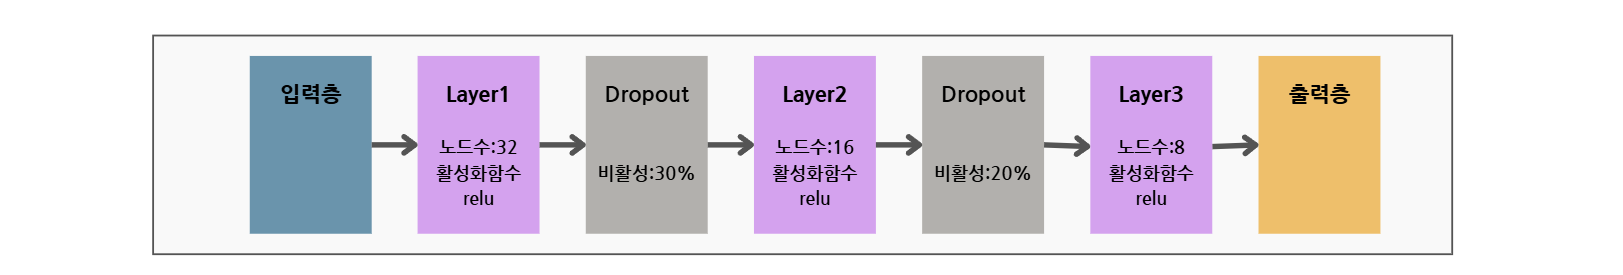

In [31]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
dl_model = Sequential()
dl_model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
dl_model.add(Dropout(0.3))
dl_model.add(Dense(16, activation='relu'))
dl_model.add(Dropout(0.2))
dl_model.add(Dense(8, activation='relu'))
dl_model.add(Dense(1, activation='linear'))

dl_model.compile(optimizer='adam', loss='mse')

es = EarlyStopping(monitor='val_loss', patience=5)
mc = ModelCheckpoint(filepath='best_dl_model.keras', monitor='val_loss', save_best_only=True)

history = dl_model.fit(X_train_scaled, y_train,
                        epochs=50, batch_size=32,
                        validation_data=(X_val_scaled, y_val),
                        callbacks=[es,mc])

C:\Users\kun99\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 569.8325 - val_loss: 194.3757
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 101.5322 - val_loss: 29.3126
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 72.3665 - val_loss: 27.3660
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 67.5607 - val_loss: 28.0287
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 62.6252 - val_loss: 26.5913
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 58.6342 - val_loss: 25.2755
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 57.5477 - val_loss: 25.2846
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 56.4727 - val_loss: 25.3792
Epoch 9/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 53.0432 - val_loss: 24.9934
Epoch 10/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 53.0196 - val_loss: 25.3280
Epoch 11/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 52.8461 - val_loss: 23.7548
Epoch 12/50
125/125 ━━━━━━━

In [ ]:
# (11-1) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (11-2) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (11-3) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (11-4) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (11-5) 여기에 답안을 입력하세요(실행 불필요).

#### **12. 앞서 만든 딥러닝 모델의 일반화 성능(Generalization Performance)을 평가하려고 합니다. matplotlib 라이브러리 활용해서, 학습 MSE와 검증 MSE의 변화를 그래프로 시각화하세요.**
---
* 아래 가이드에 따라 MSE 변화를 시각화하는 코드를 완성하세요.
    - **`matplotlib.pyplot`** 라이브러리를 활용하세요.
    - 한 개의 그래프에 훈련 손실(**`loss`**)과 검증 손실(**`val_loss`**)을 함께 표시하세요.
    - 그래프 제목은 **'Model Loss'**, x축 라벨은 **'Epoch'**, y축 라벨은 **'Loss'** 로 설정하세요.
    - 위 2가지 각각의 범례를 **'Loss'**,**'Val_Loss'** 로 표시하세요.
---

In [ ]:
#(12) 여기에 답안코드를 작성하고 실행하세요.

#### **13. 최종 평가를 위해 미리 분리해 둔 검증 데이터셋(test_df)을 활용하여 모델의 실제 예측 성능을 검증하세요. 모델의 성능 평가는 학습 과정뿐만 아니라, 전혀 본 적 없는 데이터(Unseen Data)에 대한 일반화 능력을 확인하는 과정입니다. 저장된 최적의 모델을 불러와 최종 평가 지표를 산출하세요.**
---
* **대상 데이터**: **`test_df`**, **`X_train`**, **`scaler`**, **`best_dl_model.keras`**
* **검증 데이터셋 준비**
    - **`test_df`** 에서 타깃 변수인 **`travel_time`** 을 제외한 피처(**`X_test`**)와 타겟(**`y_test`**)을 분리하세요.
    - **`X_test`** 의 컬럼 순서를 훈련 데이터(**`X_train`**)의 컬럼 순서와 동일하게 맞추세요.
* **데이터 변환 및 모델 로드**
    - 훈련 시 사용한 **`scaler`** 를 사용하여 **`X_test`** 를 변환하고, 결과를 **`X_test_scaled`** 에 저장하세요.
    - 문제 11에서 저장한 최적 모델(**'best_dl_model.keras'**)을 로드하여 **`loaded_model`** 변수에 저장하세요.
* **최종 성능 평가 및 RMSE 계산**
    - **`evaluate`** 메소드를 사용하여 **`X_test_scaled`** 에 대한 최종 Loss(MSE) 값을 계산하고, 소수점 넷째 자리까지 반올림하여 결과를 확인하세요.
---

In [33]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
from tensorflow.keras.models import load_model

X_test = test_df.drop('travel_time', axis=1)
y_test = test_df['travel_time']
X_test = X_test[X_train.columns]

X_test_scaled = scaler.transform(X_test)
loaded_model = load_model('best_dl_model.keras')

final_mse = loaded_model.evaluate(X_test_scaled, y_test)
print(f"최종 테스트 데이터 MSE: {round(final_mse, 4)}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 27.4399
최종 테스트 데이터 MSE: 27.4399


In [ ]:
# (13-1) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (13-2) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (13-3) 여기에 답안을 입력하세요(실행 불필요).

#### **14. 학습된 딥러닝 모델을 사용하여 새로운 운행 조건 데이터에 대한 주행 시간을 예측하고 최종 결과를 산출하시오.**

**아래 가이드에 따라 예측을 수행하고 결과를 확인하세요.**

---

- 제공된 **`new_data`** 를 학습 시 사용한 **`scaler`** 를 사용하여 스케일 처리하세요.
- 로드된 최적 모델(**`loaded_model`**)을 사용하여 스케일링된 데이터에 대한 주행 시간을 예측하세요.
- 예측된 결과를 출력하되, 소수점 둘째 자리까지 반올림하여 표시하세요.

> **<span style="color:red">아래 코드를 사전에 </span> 실행하세요.**

In [34]:
# 이 코드를 먼저 실행하세요.
# 새로운 운행 조건 데이터 (temperature, traffic_congestion 등 12개 피처)
new_data = np.array([[
    22.5, 2, 6, 0, 1, 0, 1, 0, 0, 0, 0, 0
]])

In [35]:
new_data_scaled = scaler.transform(new_data)

new_pred = loaded_model.predict(new_data_scaled)[0][0]

print(round(new_pred, 2))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
35.47


C:\Users\kun99\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
